Fertig.


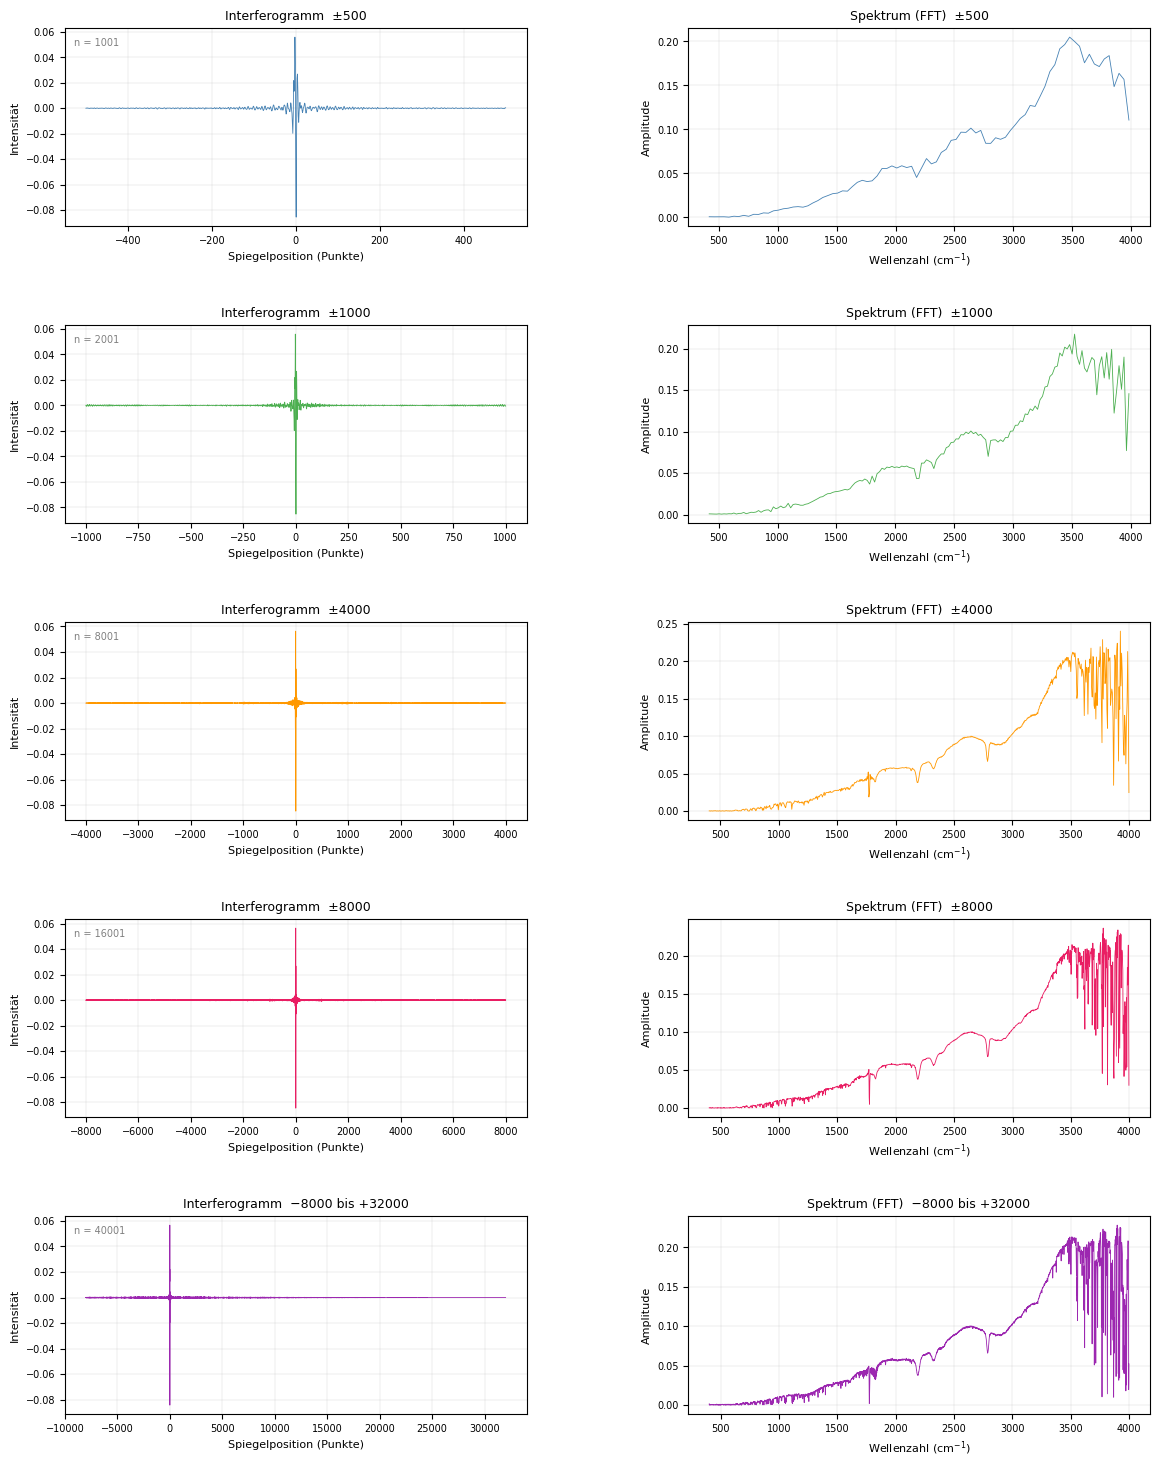

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq, fftshift

# ── Hilfsfunktion: ASC einlesen ───────────────────────────────────────────────
def lese_asc(pfad):
    x, y = [], []
    with open(pfad, "r", encoding="latin-1") as f:
        daten = False
        for zeile in f:
            z = zeile.strip()
            if z == "#DATA":
                daten = True; continue
            if daten and z:
                t = z.split()
                if len(t) == 2:
                    try:
                        x.append(float(t[0]))
                        y.append(float(t[1]))
                    except ValueError:
                        pass
    x, y = np.array(x), np.array(y)
    idx = np.argsort(x)
    return x[idx], y[idx]

# ── Dateien ───────────────────────────────────────────────────────────────────
dateien = [
    ("Interferogramm_2_500.asc",   "±500"),
    ("Interferogramm_2_1000.asc",  "±1000"),
    ("Interferogramm_2_4000.asc",  "±4000"),
    ("Interferogramm_2_8000.asc",  "±8000"),
    ("Interferogramm_2_32000.asc", "−8000 bis +32000"),
]

# Schrittweite aus erster Datei bestimmen
# Aus der Anleitung: step_size in cm → Wellenzahl = freq / step_size
# Bekannte Wasserdampflinie ~1601 cm⁻¹ zur Kalibrierung nutzen
# Schrittweite = 0.00002384185791015625 laut Header (in cm? prüfen)
header_step = 0.00002384185791015625  # aus #GR Zeile

# ── Große Figure: 5 Zeilen × 2 Spalten (links Interferogramm, rechts Spektrum)
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
plt.subplots_adjust(hspace=0.5, wspace=0.35)

farben = ["steelblue", "#4caf50", "#ff9800", "#e91e63", "#9c27b0"]

for i, ((pfad, label), farbe) in enumerate(zip(dateien, farben)):
    x, y = lese_asc(pfad)
    n = len(x)
    dx = np.mean(np.diff(x))  # Schrittweite in Punkten (hier =1)

    # ── Interferogramm (links) ────────────────────────────────────────────────
    ax_igr = axes[i, 0]
    ax_igr.plot(x, y, color=farbe, linewidth=0.6)
    ax_igr.set_xlabel("Spiegelposition (Punkte)", fontsize=8)
    ax_igr.set_ylabel("Intensität", fontsize=8)
    ax_igr.set_title(f"Interferogramm  {label}", fontsize=9)
    ax_igr.tick_params(labelsize=7)
    ax_igr.grid(True, linewidth=0.3, alpha=0.5)

    # ── FFT → Spektrum (rechts) ───────────────────────────────────────────────
    ax_sp = axes[i, 1]

    # Schrittweite in cm (aus Header)
    dx_cm = header_step  # cm pro Punkt

    # FFT
    Y = fft(y)
    freqs = fftfreq(n, d=dx_cm)  # Wellenzahl in cm⁻¹

    # Nur positive Frequenzen
    pos = freqs > 0
    wn_fft = freqs[pos]
    amp = np.abs(Y[pos])

    # Nur sinnvollen Bereich zeigen: 400–4000 cm⁻¹
    maske = (wn_fft >= 400) & (wn_fft <= 4000)

    ax_sp.plot(wn_fft[maske], amp[maske], color=farbe, linewidth=0.6)
    ax_sp.set_xlabel("Wellenzahl (cm$^{-1}$)", fontsize=8)
    ax_sp.set_ylabel("Amplitude", fontsize=8)
    ax_sp.set_title(f"Spektrum (FFT)  {label}", fontsize=9)
    ax_sp.tick_params(labelsize=7)
    ax_sp.grid(True, linewidth=0.3, alpha=0.5)

    # Anzahl Punkte als Info
    ax_igr.text(0.02, 0.95, f"n = {n}", transform=ax_igr.transAxes,
                fontsize=7, va="top", color="gray")

plt.savefig("interferogramme_alle.png",
            dpi=130, bbox_inches="tight")
print("Fertig.")